# dirFR sample plots — primacy vs recency initiation

This notebook reuses `analyses.spc_sess` and `analyses.pfr_sess` from `analyses.py`
— the per-session computation functions, but bypasses the groupby wrappers that
were written for the old MTurk design's stimulus conditions.

In [481]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import analyses.spc as spc
import analyses.linreg as linreg
import analyses.pfr as pfr
import analyses.mwr as mwr 
import analyses.r1_intrusion as r1_intrusion
import analyses.rt_init as rt_init
import analyses.pli_eli as pli_eli
import analyses.irt as irt 
import analyses.tcl as tcl
import analyses.lcrp as lcrp
import analyses.scl as scl
import analyses.statistics as stat_tests
from scipy.stats import wilcoxon
import warnings; warnings.filterwarnings('ignore')
from data.spellcheck import spellcheck_recalls_dl
from data.prolific_quality import filter_sessions_by_quality
from data.recall_inspection import inspect_list_recall

## 0. Load and Clean

In [212]:
# Loads the most recent pulled CSV file from data/data_storage 
data_dir = Path('data/data_storage') # create path to folder 
try:
    data_path = max(data_dir.glob('dirfr_trials*.csv'), key=lambda p: p.stat().st_mtime) # get most recent trial csv
except ValueError:
    raise FileNotFoundError(f'No dirfr_trials*.csv files found in {data_dir}')
raw = pd.read_csv(data_path)
print(f'Loaded {data_path}')

Loaded data\data_storage\dirfr_trials_20260606_171051.csv


In [213]:
# Manual Exclusion
exclude_pid = ['5ece82a1ba09f524e15d973b', '602fd11faa844cd2d0fd5818', '69f0ef2a58d846e3bbe5a68f']
print(f'Before exclusion: {len(raw)} rows')
raw = raw[~raw['prolific_pid'].isin(exclude_pid)].copy()
print(f'After exclusion: {len(raw)} rows')
print(f'Excluded data (Prolific IDs: {exclude_pid})')

Before exclusion: 186359 rows
After exclusion: 180967 rows
Excluded data (Prolific IDs: ['5ece82a1ba09f524e15d973b', '602fd11faa844cd2d0fd5818', '69f0ef2a58d846e3bbe5a68f'])


In [214]:
# Keep only word-presentation and recall rows - analyses.spc_sess / pfr_sess use these
df = raw[raw['type'].isin(['WORD', 'REC_WORD'])].copy()

# Ensure numeric dtypes (raw CSV mixes schemas across rows)
for col in ['serial_position', 'list', 'session', 'l_length', 'rt']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Check
type(df['serial_position'].iloc[0]), type(df['list'].iloc[0]), type(df['session'].iloc[0]), type(df['l_length'].iloc[0]), type(df['rt'].iloc[0])

(numpy.float64, numpy.float64, numpy.int64, numpy.float64, numpy.float64)

In [215]:
# Build lookup: presented WORD -> serial position
word_rows = df[df['type'] == 'WORD'].copy()
word_rows['word_key'] = word_rows['word'].str.lower().str.strip()
word_maps = word_rows.set_index(
    ['prolific_pid', 'session', 'list', 'word_key']
)['serial_position'].to_dict()

# recompute serial positions for REC_WORD
def recover_sp(row):
    if row['type'] != 'REC_WORD':
        return row['serial_position']
    if pd.isna(row['rec_word']) or str(row['rec_word']).strip() in ['', 'null']:
        return 99
    key = (row['prolific_pid'], row['session'], row['list'], str(row['rec_word']).lower().strip())
    return word_maps.get(key, 88) # return serial position if found else 88 

df['serial_position'] = df.apply(recover_sp, axis=1)
df = spellcheck_recalls_dl(df) # add spellcheck following original study, Levenshtein dist <= 1 

Damerau-Levenshtein spellcheck corrected 2222 recall(s).


In [216]:
df_before_quality = df.copy()
df_after_quality = filter_sessions_by_quality(df_before_quality, raw)

before_sessions = df_before_quality[['prolific_pid', 'session']].drop_duplicates()
after_sessions = df_after_quality[['prolific_pid', 'session']].drop_duplicates()

excluded_sessions = (
    before_sessions
    .merge(after_sessions, on=['prolific_pid', 'session'], how='left', indicator=True)
    .query("_merge == 'left_only'")
    .drop(columns='_merge')
    .sort_values(['prolific_pid', 'session'])
)

excluded = len(excluded_sessions)

print(f"Excluded sessions by quality criteria: {excluded}")
display(excluded_sessions)

df = df_after_quality


Participant 68d850c1c461a91aa0382734 in session 1 had 6 trials with zero correct recalls.
Participant 69dc70961c94f47c2fdced04 in session 0 took notes.
Participant 6a02a3d567b030856033eb52 in session 0 took notes.
Excluded sessions by quality criteria: 3


,prolific_pid,session
295,68d850c1c461a91aa0382734,1
174,69dc70961c94f47c2fdced04,0
313,6a02a3d567b030856033eb52,0


## 1. Inspection

In [217]:
study_ids = df['study_id'].unique()
print(f"Unique study IDs in the dataset: {study_ids}")

Unique study IDs in the dataset: <StringArray>
['69d46e02eb60e403061e3838', '69d471615d93c0c79dee79ab',
 '69d471fc7a8b81688aee48f7', '69d472c7196fbc6a00542c17',
 '69d4731bcc7b5579cfac3f7f']
Length: 5, dtype: str


In [218]:
# Metadata Inspection
session_info = df[['prolific_pid', 'session', 'initiation_condition']].drop_duplicates(['prolific_pid', 'session'])
twoplus_sessions = session_info.groupby('prolific_pid')['session'].nunique().loc[lambda s: s > 2]
print(f'{len(df)} rows across {session_info["prolific_pid"].nunique()} participants, {len(session_info)} sessions')
print(f"Condition breakdown by session: {session_info['initiation_condition'].value_counts().to_dict()}")
print(f'Participants with 2+ included session: {len(twoplus_sessions)}')

print("Total Sessions Completed:", session_info['session'].nunique())
counts = session_info['session'].value_counts().sort_index()
counts.index = [f"Session {i}" for i in counts.index]
print(counts)

145521 rows across 176 participants, 468 sessions
Condition breakdown by session: {'primacy': 260, 'recency': 208}
Participants with 2+ included session: 84
Total Sessions Completed: 5
Session 0    175
Session 1    128
Session 2     86
Session 3     49
Session 4     30
Name: count, dtype: int64


In [235]:
# Per-Subject Inspection
pid = '66a641fad795279aac9120b8' # (replace with actual Prolific ID of interest)

# 1) Number of sessions completed
n_sessions = session_info[session_info['prolific_pid'] == pid]['session'].nunique()

# 2) Condition per session
print(f"Condition per Session:")
for i in range(n_sessions):
    condition = session_info[(session_info['prolific_pid'] == pid) & (session_info['session'] == i)]['initiation_condition'].iloc[0]
    print(f"Session {i}: {condition}")

# 3) Mean words recalled per list per session
print(f"Mean Words Recalled per Session:")
for i in range(n_sessions):
    data = df_before_quality[(df_before_quality['prolific_pid'] == pid) & (df_before_quality['session'] == i)]
    mean_words = mwr.mwr_sess(data)
    print(f"Session {i}: {mean_words}")

Condition per Session:
Session 0: primacy
Session 1: primacy
Session 2: primacy
Session 3: primacy
Session 4: primacy
Mean Words Recalled per Session:
Session 0: 6.166666666666667
Session 1: 5.25
Session 2: 5.25
Session 3: 4.916666666666667
Session 4: 5.5


In [355]:
# Per-List Inspection
pid = '6a1649857384eddeae867230' # (replace with actual Prolific ID of interest)
session = 0
list_num = 5

selected = df.query("prolific_pid == @pid and session == @session and list == @list_num")
condition = selected['initiation_condition'].dropna().iloc[0]
ll = int(selected['l_length'].dropna().iloc[0])
recalls = selected[selected['type'] == 'REC_WORD']['serial_position']
correct_unique = recalls[(recalls >= 1) & (recalls <= ll)].astype(int).nunique()

print(f'Participant {pid}, Session {session}, List {list_num}')
print(f'Initiation direction: {condition}')
print(f'Words recalled: {correct_unique}')
inspect_list_recall(df, pid, session, list_num)

IndexError: single positional indexer is out-of-bounds

## T-test for non-random attrition

In [223]:
filtered_p0ids = df[df['session'] == 0]['prolific_pid'].unique()
filtered_p1ids = df[df['session'] == 1]['prolific_pid'].unique()
p0_not_p1 = set(filtered_p0ids) - set(filtered_p1ids)
p0_not_p1_df = df[(df['prolific_pid'].isin(p0_not_p1)) & (df['session'] == 0)]
p0_with_p1_df = df[(df['prolific_pid'].isin(filtered_p1ids)) & (df['session'] == 0)]

In [224]:
mwr_p0notp1 = mwr.mwr(p0_not_p1_df)
mwr_p1plus = mwr.mwr(p0_with_p1_df)

In [225]:
from scipy import stats

mwr_0 = mwr_p0notp1['mwr'].dropna()
mwr_1 = mwr_p1plus['mwr'].dropna()

print(f"n (p0 not p1) = {len(mwr_0)}")
print(f"mean (p0 not p1) = {mwr_0.mean():.3f}")
print(f"n (p1 plus) = {len(mwr_1)}")
print(f"mean (p1 plus) = {mwr_1.mean():.3f}")

t_stat, p_value = stats.ttest_ind(mwr_0, mwr_1, equal_var=False, nan_policy='omit')
print(f"T-statistic = {t_stat:.3f}")
print(f"P-value = {p_value:.4f}")

n (p0 not p1) = 48
mean (p0 not p1) = 7.003
n (p1 plus) = 127
mean (p1 plus) = 7.453
T-statistic = -0.875
P-value = 0.3839


## 2. Demographics


In [226]:
included_pids = df['prolific_pid'].unique()
demog_raw = raw[raw['prolific_pid'].isin(included_pids)].copy()

In [227]:
age_df = (
    demog_raw.query("type == 'age'")[['prolific_pid', 'age']]
    .dropna()
    .drop_duplicates('prolific_pid')
)

age_df['age'] = pd.to_numeric(age_df['age'], errors='coerce')
age_stats = age_df['age'].describe()
age_stats 

count    176.000000
mean      25.096591
std        3.405339
min       18.000000
25%       22.000000
50%       25.500000
75%       28.000000
max       30.000000
Name: age, dtype: float64

In [228]:
gender_map = {
    0: 'Male',
    1: 'Female',
    2: 'Other',
    3: 'Prefer not to answer',
}

gender_df = (
    demog_raw.query("type == 'gender'")[['prolific_pid', 'response']]
    .drop_duplicates('prolific_pid')
    .copy()
)

gender_overrides = {
    '65cb7d52b59b7dd58392e0ba': 'Female'
}

gender_df['gender'] = (
    pd.to_numeric(gender_df['response'], errors='coerce')
    .map(gender_map)
    .fillna('Unknown')
)

gender_df.head(5)

,prolific_pid,response,gender
2413,69eb1df8219c8467eb86f444,1,Female
2674,6993ef10052ab64910f5b6cc,1,Female
2928,69d0c2ae9394bed26d131574,1,Female
3214,663bb62ffe083ca847014fbb,0,Male
3515,5a8895f0f1408d0001769b7b,1,Female


In [229]:
demographics_df = age_df.merge(
    gender_df[['prolific_pid', 'gender']],
    on='prolific_pid',
    how='outer'
)

demographics_df.head(5)

,prolific_pid,age,gender
0,5a285307df86d80001455de5,29.0,Male
1,5a8895f0f1408d0001769b7b,28.0,Female
2,5bf116a61e78580001dc4842,26.0,Male
3,5d96eeed1998fb00177f6b71,29.0,Female
4,5f1db570f7e0002b7eb1c1dd,26.0,Female


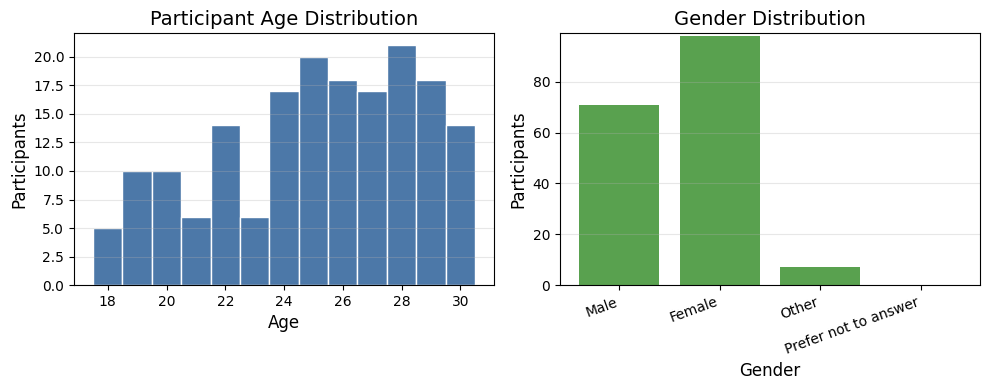

In [230]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
bins = np.arange(
    demographics_df['age'].min() - 0.5,
    demographics_df['age'].max() + 1.5,
    1,
)
ax[0].hist(demographics_df['age'].dropna(), bins=bins, color='#4c78a8', edgecolor='white')
ax[0].set_xlabel('Age', fontsize=12)
ax[0].set_ylabel('Participants', fontsize=12)
ax[0].set_title('Participant Age Distribution', fontsize=14)
ax[0].set_xticks(np.arange(demographics_df['age'].min(), demographics_df['age'].max() + 1, 2))
ax[0].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/age_histogram.png', dpi=150)

gender_counts = demographics_df['gender'].value_counts().reindex(gender_map.values(), fill_value=0)
ax[1].bar(gender_counts.index, gender_counts.values, color='#59a14f')
ax[1].set_xlabel('Gender', fontsize=12)
ax[1].set_ylabel('Participants', fontsize=12)
ax[1].set_title('Gender Distribution', fontsize=14)
ax[1].set_ylim(0, max(gender_counts.max() + 1, 1))
ax[1].grid(axis='y', alpha=0.3)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('figures/gender_distribution.png', dpi=150)
plt.show()

## Correct Filtering (FINAL ALGO)

In [231]:
filtered_p0ids = df[df['session'] == 0]['prolific_pid'].unique()
filtered_p1ids = df[df['session'] == 1]['prolific_pid'].unique()
filtered_p2ids = df[df['session'] == 2]['prolific_pid'].unique()
filtered_participants = set(filtered_p0ids) & set(filtered_p1ids) & set(filtered_p2ids)
filtered_df = df[(df['prolific_pid'].isin(filtered_participants)) & (df['session'] >= 1)]
print(filtered_df[filtered_df['session'] == 1]['prolific_pid'].nunique())
print(filtered_df[filtered_df['session'] == 2]['prolific_pid'].nunique())
print(filtered_df[filtered_df['session'] == 3]['prolific_pid'].nunique())
print(filtered_df[filtered_df['session'] == 4]['prolific_pid'].nunique())

84
84
49
30


In [232]:
df_temp = filtered_df[['prolific_pid', 'initiation_condition', 'session']].drop_duplicates()

counts = (
    df_temp.groupby('prolific_pid')['initiation_condition']
    .unique().explode().value_counts()
)

print(counts)

initiation_condition
primacy    70
recency    61
Name: count, dtype: int64


In [356]:
primacy_df = filtered_df[filtered_df['initiation_condition'] == 'primacy']
primacy_age_df = (
    demog_raw.query("type == 'age'")[['prolific_pid', 'age']]
    .dropna()
    .drop_duplicates('prolific_pid')
)
primacy_age = primacy_df[['prolific_pid']].drop_duplicates().merge(primacy_age_df, on='prolific_pid', how='left')['age']
primacy_age.describe()

count    70.000000
mean     25.071429
std       3.406394
min      18.000000
25%      22.000000
50%      25.000000
75%      28.000000
max      30.000000
Name: age, dtype: float64

In [357]:
recency_df = filtered_df[filtered_df['initiation_condition'] == 'recency']
recency_age_df = (
    demog_raw.query("type == 'age'")[['prolific_pid', 'age']]
    .dropna()
    .drop_duplicates('prolific_pid')
)
recency_age = recency_df[['prolific_pid']].drop_duplicates().merge(recency_age_df, on='prolific_pid', how='left')['age']
recency_age.describe()

count    61.000000
mean     24.606557
std       3.372826
min      18.000000
25%      22.000000
50%      25.000000
75%      28.000000
max      30.000000
Name: age, dtype: float64

In [358]:


age_df = (
    demog_raw.query("type == 'age'")[['prolific_pid', 'age']]
    .dropna()
    .drop_duplicates('prolific_pid')
)

age_df['age'] = pd.to_numeric(age_df['age'], errors='coerce')
age_stats = age_df['age'].describe()
age_stats 

count    176.000000
mean      25.096591
std        3.405339
min       18.000000
25%       22.000000
50%       25.500000
75%       28.000000
max       30.000000
Name: age, dtype: float64

## F7(a-b). Serial Position Curve (SPC)

In [364]:
spc_df = spc.spc_df(filtered_df)
sp_cols = [c for c in spc_df.columns if c.startswith('sp_')]
spc_df.head(5)

,prolific_pid,session,initiation_condition,sp_1,sp_2,sp_3,sp_4,sp_5,sp_6,sp_7,...,sp_11,sp_12,sp_13,sp_14,sp_15,sp_16,sp_17,sp_18,sp_19,sp_20
0,5a285307df86d80001455de5,1,recency,0.833333,0.500000,0.416667,0.750000,0.250000,0.333333,0.333333,...,0.333333,0.083333,0.000000,0.083333,0.250000,0.333333,0.166667,0.500000,0.916667,1.000000
1,5a285307df86d80001455de5,2,recency,0.916667,0.583333,0.416667,0.166667,0.083333,0.250000,0.333333,...,0.333333,0.166667,0.166667,0.250000,0.166667,0.250000,0.500000,0.666667,0.916667,1.000000
2,5a285307df86d80001455de5,3,recency,0.750000,0.916667,0.250000,0.333333,0.416667,0.333333,0.250000,...,0.333333,0.416667,0.333333,0.000000,0.083333,0.416667,0.583333,0.666667,0.916667,1.000000
3,5a285307df86d80001455de5,4,primacy,1.000000,0.750000,0.666667,0.500000,0.083333,0.500000,0.333333,...,0.166667,0.250000,0.000000,0.000000,0.083333,0.083333,0.250000,0.333333,0.750000,1.000000
4,5bf116a61e78580001dc4842,1,primacy,0.750000,0.833333,0.500000,0.333333,0.250000,0.333333,0.250000,...,0.333333,0.333333,0.333333,0.166667,0.250000,0.333333,0.416667,0.083333,0.583333,0.833333


Participants are the unit of analysis. If a participant completed more than one session in the same condition, those sessions are averaged first; condition means and 95% SE intervals are then computed across participants.

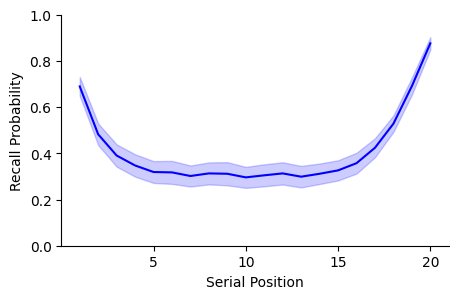

In [365]:
overall_spc = spc.spc_plot_overall(spc_df, path=f'figures/7a_spc_overall.pdf')

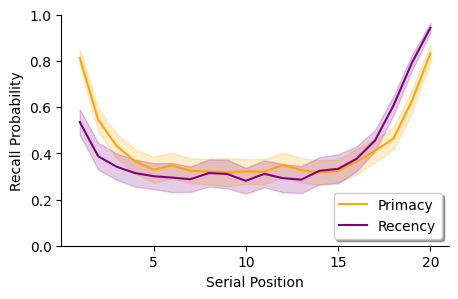

In [366]:
spc_bycond = spc.spc_plot(spc_df, path=f'figures/7b_spc_by_condition.pdf')

In [ ]:
spc_means = spc_df[spc_df['initiation_condition'] == 'primacy'][sp_cols].mean()

# Replace with your actual 20 data points from the primacy curve
primacy_curve = np.array(spc_means.values)

left_half = primacy_curve[:10]
right_half_reversed = primacy_curve[10:][::-1]

statistic, p_value = wilcoxon(left_half, right_half_reversed)

print(f"Statistic: {statistic}, p-value: {p_value}")

Statistic: 16.0, p-value: 0.275390625


## F7(c): Linear Regression Gradient Trend

In [382]:
linreg_df = spc_df.apply(linreg.prim_rec_lr, axis=1)
linreg_df.head(5)

,prolific_pid,session,initiation_condition,prim_slope,prim_intercept,rec_slope,rec_intercept
0,5a285307df86d80001455de5,1,recency,-0.091667,0.825000,0.208333,-0.041667
1,5a285307df86d80001455de5,2,recency,-0.208333,1.058333,0.191667,0.091667
2,5a285307df86d80001455de5,3,recency,-0.125000,0.908333,0.150000,0.266667
3,5a285307df86d80001455de5,4,primacy,-0.208333,1.225000,0.233333,-0.216667
4,5bf116a61e78580001dc4842,1,primacy,-0.150000,0.983333,0.116667,0.100000


In [395]:
stat_tests.one_sample(linreg_df, ["prim_slope", "rec_slope"])

,initiation_condition,measure,test,n,t_stat,p_val,dof,cohen_d,p_val_fdr
0,primacy,prim_slope,one_sample,70,-14.871150,3.294417e-23,69,-1.777442,9.151158e-23
1,primacy,rec_slope,one_sample,70,15.442259,4.423817e-24,69,1.845703,1.843257e-23
2,recency,prim_slope,one_sample,61,-7.778558,1.170156e-10,60,-0.995942,2.437825e-10
3,recency,rec_slope,one_sample,61,18.152168,4.735738e-26,60,2.324147,3.946449e-25


In [396]:
stat_tests.condition_contrast(linreg_df, ["prim_slope", "rec_slope"], paired=False)

,measure,test,n,t_stat,p_val,dof,cohen_d,p_val_fdr
0,prim_slope,welch,61,-5.825499,4.298432e-08,128.866564,-1.008468,1.289530e-07
1,rec_slope,welch,61,-2.881761,4.649690e-03,126.105702,-0.505199,6.974536e-03


In [397]:
linreg_df.groupby("prolific_pid")["initiation_condition"].nunique().value_counts()

initiation_condition
2    47
1    37
Name: count, dtype: int64

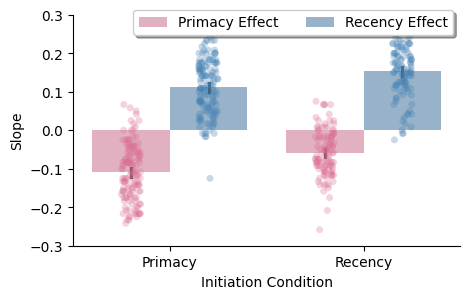

In [398]:
linreg_plot = linreg.plot_linreg(linreg_df, path=f'figures/7c_prim_rec_slopes.pdf')

## F7(d): PFR

In [ ]:
pfr_df = pfr.pfr(filtered_df)
pfr_df.head(5)

,prolific_pid,session,initiation_condition,sp_1,sp_2,sp_3,sp_4,sp_5,sp_6,sp_7,...,sp_11,sp_12,sp_13,sp_14,sp_15,sp_16,sp_17,sp_18,sp_19,sp_20
0,5a285307df86d80001455de5,1,recency,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,5a285307df86d80001455de5,2,recency,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,5a285307df86d80001455de5,3,recency,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,5a285307df86d80001455de5,4,primacy,0.916667,0.083333,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5bf116a61e78580001dc4842,1,primacy,0.700000,0.200000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0


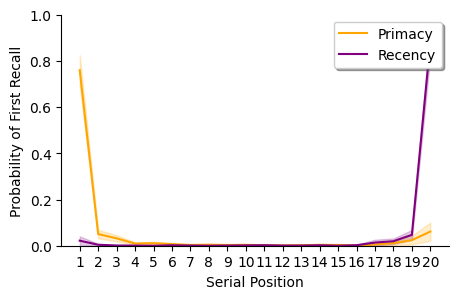

In [400]:
pfr.pfr_plot(pfr_df, path=f'figures/7d_pfr_by_condition.pdf')

In [401]:
# average sessions within participant-condition first
participant_df = (
    pfr_df
    .groupby(["prolific_pid", "initiation_condition"], as_index=False)
    [[f"sp_{i}" for i in range(1, 21)]]
    .mean()
)

# create grouped serial-position bins
participant_df["SP 1-5"] = participant_df[[f"sp_{i}" for i in range(1, 6)]].sum(axis=1)
participant_df["SP 6-15"] = participant_df[[f"sp_{i}" for i in range(6, 16)]].sum(axis=1)
participant_df["SP 16-20"] = participant_df[[f"sp_{i}" for i in range(16, 21)]].sum(axis=1)

binned_percent = (
    participant_df
    .groupby("initiation_condition")[["SP 1-5", "SP 6-15", "SP 16-20"]]
    .mean()
    .reset_index()
)

binned_percent

,initiation_condition,SP 1-5,SP 6-15,SP 16-20
0,primacy,0.862351,0.034204,0.103445
1,recency,0.027625,0.010519,0.961856


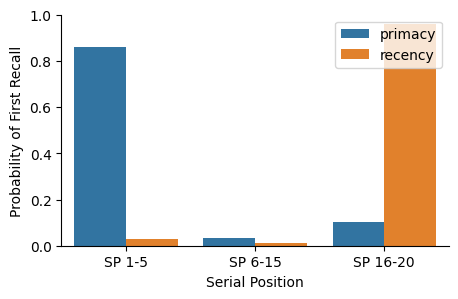

In [402]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = binned_percent.melt(
    id_vars="initiation_condition",
    var_name="serial_position_bin",
    value_name="prob_first_recall"
)

plt.figure(figsize=(5, 3))

sns.barplot(
    data=plot_df,
    x="serial_position_bin",
    y="prob_first_recall",
    hue="initiation_condition",
)

plt.xlabel("Serial Position")
plt.ylabel("Probability of First Recall")
plt.ylim(0, 1)
plt.legend(loc='upper right')
sns.despine()
plt.show()


## F8(a-b): Mean words recalled

For each session, `mwr_sess` returns the average number of correct recalls
per list.

In [507]:
mwr_df = mwr.mwr(filtered_df)
mwr_df.head(5)

,prolific_pid,session,initiation_condition,mwr
0,5a285307df86d80001455de5,1,recency,7.416667
1,5a285307df86d80001455de5,2,recency,7.750000
2,5a285307df86d80001455de5,3,recency,8.750000
3,5a285307df86d80001455de5,4,primacy,7.166667
4,5bf116a61e78580001dc4842,1,primacy,7.583333


In [508]:
stat_tests.condition_contrast(mwr_df, ["mwr"], paired=False)

,measure,test,n,t_stat,p_val,dof,cohen_d,p_val_fdr
0,mwr,welch,61,0.602182,0.548128,126.794458,0.105424,0.548128


In [509]:
mwr2_df = mwr_df[mwr_df['session']==2]
stat_tests.condition_contrast(mwr2_df, ["mwr"], paired=False)

,measure,test,n,t_stat,p_val,dof,cohen_d,p_val_fdr
0,mwr,welch,36,0.799606,0.426364,78.131696,0.174526,0.426364


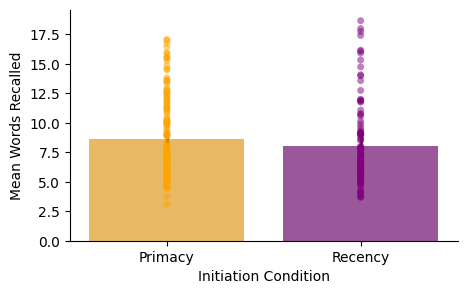

In [512]:
mwr.mwr_plot(mwr_df, path=f'figures/8a_mwr_by_condition.pdf')

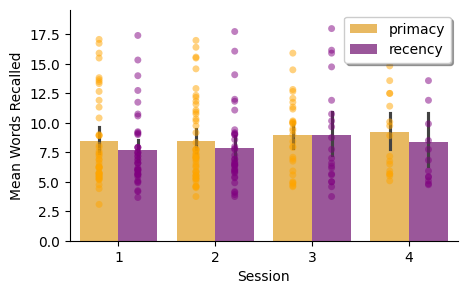

In [513]:
mwr.mwr_plot_by_session(mwr_df, path=f'figures/8b_mwr_by_condition_by_session.pdf')

## F9(a-b) R1 Intrusion Probability

In [514]:
r1_intrusion_data = r1_intrusion.r1_intrusion_df(filtered_df)
r1_intrusion_data.head(5)

,prolific_pid,session,initiation_condition,prop_wrong
0,5a285307df86d80001455de5,1,recency,0.000000
1,5a285307df86d80001455de5,2,recency,0.000000
2,5a285307df86d80001455de5,3,recency,0.000000
3,5a285307df86d80001455de5,4,primacy,0.000000
4,5bf116a61e78580001dc4842,1,primacy,0.166667


In [515]:
summary = (
    r1_intrusion_data
    .groupby("initiation_condition")["prop_wrong"]
    .agg(mean="mean", sd="std")
)

print(summary)

                          mean        sd
initiation_condition                    
primacy               0.064477  0.092616
recency               0.031061  0.053970


In [516]:
stat_tests.condition_contrast(r1_intrusion_data[r1_intrusion_data["session"]==1], ["prop_wrong"], paired=False)

,measure,test,n,t_stat,p_val,dof,cohen_d,p_val_fdr
0,prop_wrong,welch,41,2.95023,0.004659,54.93317,0.632637,0.004659


In [517]:
for sess in range(1,5):
    r1_intrusion_prim = r1_intrusion_data[(r1_intrusion_data['session'] == sess) & (r1_intrusion_data['initiation_condition'] == 'primacy')]['prop_wrong'].mean()
    print(f'Session {sess} - Primacy: = {r1_intrusion_prim:.3f}')
    r1_intrusion_rec = r1_intrusion_data[(r1_intrusion_data['session'] == sess) & (r1_intrusion_data['initiation_condition'] == 'recency')]['prop_wrong'].mean()
    print(f'Session {sess} - Recency: = {r1_intrusion_rec:.3f}')

Session 1 - Primacy: = 0.078
Session 1 - Recency: = 0.024
Session 2 - Primacy: = 0.057
Session 2 - Recency: = 0.039
Session 3 - Primacy: = 0.060
Session 3 - Recency: = 0.050
Session 4 - Primacy: = 0.059
Session 4 - Recency: = 0.000


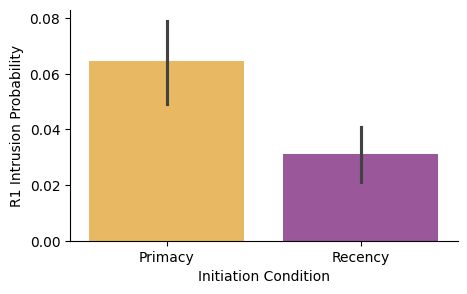

In [519]:
r1_intrusion.r1_intrusion_overall(r1_intrusion_data, path=f'figures/9a_r1_intrusion_overall.pdf')

## F9(c) R1 Response Time

In [426]:
rt_init_df = rt_init.rt_init_df(filtered_df)
rt_init_df.head(5)

,prolific_pid,session,initiation_condition,rt_initial
0,5a285307df86d80001455de5,1,recency,820.533333
1,5a285307df86d80001455de5,2,recency,1493.491667
2,5a285307df86d80001455de5,3,recency,892.050000
3,5a285307df86d80001455de5,4,primacy,2623.766667
4,5bf116a61e78580001dc4842,1,primacy,2840.130000


In [427]:
rt_init_df.groupby("initiation_condition")["rt_initial"].agg(mean="mean", sd="std")

,mean,sd
initiation_condition,,
primacy,2167.019142,1578.705870
recency,1434.036234,913.281436


In [428]:
stat_tests.condition_contrast(rt_init_df, ["rt_initial"], paired=False)

,measure,test,n,t_stat,p_val,dof,cohen_d,p_val_fdr
0,rt_initial,welch,61,3.040022,0.002901,120.83113,0.518322,0.002901


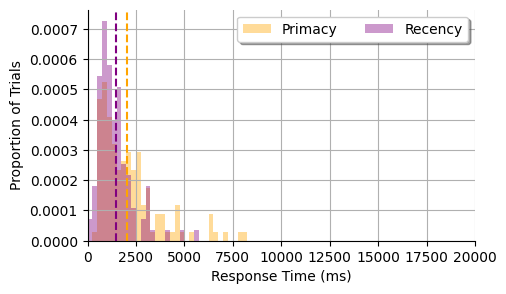

In [433]:
rt_init_plot = rt_init.rt_init_plot(rt_init_df, path=f'figures/9b_rt_init.pdf')

## F10(A-B) PLIs and ELIs

In [501]:
plieli_df = pli_eli.intrusion_rates(filtered_df)
plieli_df.head(10)

,prolific_pid,session,initiation_condition,eli,pli
0,5a285307df86d80001455de5,1,recency,0.666667,0.250
1,5a285307df86d80001455de5,2,recency,0.250000,0.125
2,5a285307df86d80001455de5,3,recency,0.666667,0.125
3,5a285307df86d80001455de5,4,primacy,0.500000,0.000
4,5bf116a61e78580001dc4842,1,primacy,0.666667,0.250
5,5bf116a61e78580001dc4842,2,primacy,0.583333,0.125
6,5bf116a61e78580001dc4842,3,primacy,0.333333,0.125
7,5bf116a61e78580001dc4842,4,primacy,0.416667,0.125
8,608832bd3e28d0394114ffa4,1,primacy,0.833333,0.875
9,608832bd3e28d0394114ffa4,2,recency,0.166667,0.500


In [502]:
plieli_recency = plieli_df[plieli_df['initiation_condition']=='recency']
plieli_recency_eli = plieli_recency['eli'].tolist()
print(f"Recency ELI: {np.mean(plieli_recency_eli)}")
plieli_recency_pli = plieli_recency['pli'].tolist()
print(f"Recency PLI: {np.mean(plieli_recency_pli)}")

plieli_primacy = plieli_df[plieli_df['initiation_condition']=='primacy']
plieli_primacy_eli = plieli_primacy['eli'].tolist()
print(f"Primacy ELI: {np.mean(plieli_primacy_eli)}")
plieli_primacy_pli = plieli_primacy['pli'].tolist()
print(f"Primacy PLI: {np.mean(plieli_primacy_pli)}")


Recency ELI: 0.7431818181818183
Recency PLI: 0.3181818181818182
Primacy ELI: 0.6636253041362531
Primacy PLI: 0.19251824817518248


In [503]:
stat_tests.condition_contrast(plieli_df, ['pli','eli'], paired=False)

,measure,test,n,t_stat,p_val,dof,cohen_d,p_val_fdr
0,pli,welch,61,-1.769277,0.080522,82.979682,-0.323811,0.241565
1,eli,welch,61,-0.508031,0.612494,105.320244,-0.091130,0.918741


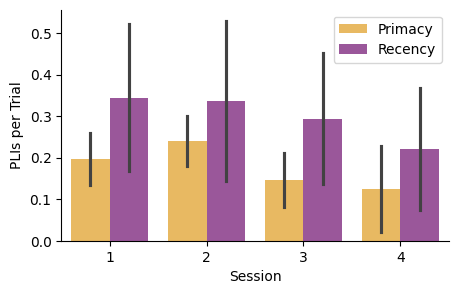

In [505]:
pli_eli.pli_plot_by_session(plieli_df, path=f'figures/10a_pli.pdf')

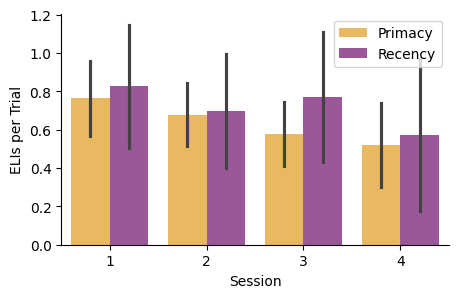

In [506]:
pli_eli.eli_plot_by_session(plieli_df, path=f'figures/10b_eli.pdf')

In [444]:
for sess in range(1,5):
    plieli_sess = plieli_df[plieli_df['session']==sess]
    print(f'Session {sess}')
    print(stat_tests.condition_contrast(plieli_sess, ['pli','eli'], paired=False))

Session 1
  measure   test   n    t_stat     p_val        dof   cohen_d  p_val_fdr
0     pli  welch  41 -1.537668  0.130434  50.007777 -0.341894   0.391301
1     eli  welch  41 -0.321488  0.748855  66.089657 -0.070935   1.000000
Session 2
  measure   test   n    t_stat     p_val        dof   cohen_d  p_val_fdr
0     pli  welch  36 -0.943960  0.350609  41.839435 -0.232798        1.0
1     eli  welch  36 -0.113192  0.910285  55.798241 -0.026525        1.0
Session 3
  measure   test   n    t_stat     p_val        dof   cohen_d  p_val_fdr
0     pli  welch  20 -1.688528  0.103578  25.345977 -0.550983   0.310733
1     eli  welch  20 -1.001508  0.325080  28.260985 -0.318495   0.487620
Session 4
  measure   test   n    t_stat     p_val        dof   cohen_d  p_val_fdr
0     pli  welch  13 -1.049303  0.305151  22.558138 -0.398545   0.915454
1     eli  welch  13 -0.219812  0.828337  19.208120 -0.085876   1.000000


## F10(C): Final IRTs

In [446]:
irt_final_df = irt.irt_final_df(filtered_df, n_final=4)
irt_final_df.head(5)

,prolific_pid,session,initiation_condition,relative_output_position,irt
0,5a285307df86d80001455de5,1,recency,-4.0,1745.900000
1,5a285307df86d80001455de5,1,recency,-3.0,1840.380000
2,5a285307df86d80001455de5,1,recency,-2.0,1908.854545
3,5a285307df86d80001455de5,1,recency,-1.0,3500.583333
4,5a285307df86d80001455de5,1,recency,0.0,5408.950000


In [457]:
for pos in range(0,5):
    print(f'Position -{pos}')
    print(stat_tests.condition_contrast(irt_final_df[irt_final_df['relative_output_position']==-1*pos], ['irt'], paired=False))

Position -0
  measure   test   n    t_stat    p_val         dof   cohen_d  p_val_fdr
0     irt  welch  61 -0.604569  0.54659  121.769622 -0.106672    0.54659
Position -1
  measure   test   n   t_stat     p_val         dof   cohen_d  p_val_fdr
0     irt  welch  61 -1.53395  0.128156  101.411427 -0.276113   0.128156
Position -2
  measure   test   n    t_stat     p_val         dof   cohen_d  p_val_fdr
0     irt  welch  61 -0.194342  0.846257  112.807401 -0.034622   0.846257
Position -3
  measure   test   n    t_stat     p_val         dof  cohen_d  p_val_fdr
0     irt  welch  61 -0.996936  0.320893  114.777705 -0.17726   0.320893
Position -4
  measure   test   n    t_stat     p_val         dof   cohen_d  p_val_fdr
0     irt  welch  60 -0.237093  0.812988  120.088346 -0.042147   0.812988


In [448]:
summary = (
    irt_final_df
    .groupby(["initiation_condition", "relative_output_position"])["irt"]
    .agg(mean="mean", sd="std")
    .reset_index()
)

print(summary)

  initiation_condition  relative_output_position         mean           sd
0              primacy                      -4.0  2927.834243  1315.317469
1              primacy                      -3.0  3103.850094  1269.902046
2              primacy                      -2.0  3522.276456  1387.787555
3              primacy                      -1.0  4221.518271  1964.122815
4              primacy                       0.0  6604.900554  3650.609271
5              recency                      -4.0  2953.890969  1537.948453
6              recency                      -3.0  3243.500509  1597.361705
7              recency                      -2.0  3571.010944  1755.577336
8              recency                      -1.0  4691.677251  2401.175765
9              recency                       0.0  6994.770794  3722.209320


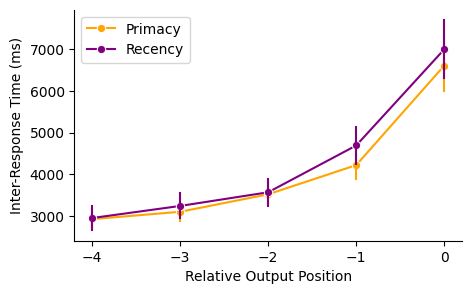

In [449]:
irt.irt_final_plot(irt_final_df, 5, path=f'figures/10c_irt_final.pdf')

In [461]:
irt_tot_df = irt.irt_tot_df(filtered_df)
irt_tot_df.head(5)

,prolific_pid,session,initiation_condition,ncr,ncr_bin,total_irt,irt_h1,irt_h2,irt_delta
0,5a285307df86d80001455de5,1,recency,5,2,20148.900000,1217.80,17296.900000,16079.100000
1,5a285307df86d80001455de5,1,recency,6,3,37961.050000,7490.00,30471.050000,22981.050000
2,5a285307df86d80001455de5,1,recency,7,3,8773.400000,2680.35,4252.500000,1572.150000
3,5a285307df86d80001455de5,1,recency,8,4,31741.566667,9052.40,22689.166667,13636.766667
4,5a285307df86d80001455de5,1,recency,9,4,22961.400000,4770.05,16986.150000,12216.100000


In [466]:
for bin in range(1, 11):
    print(f'NCR Bin {bin}')
    print(stat_tests.condition_contrast(irt_tot_df[irt_tot_df['ncr_bin']==bin], ['irt_delta'], paired=False))

NCR Bin 1
     measure   test   n    t_stat     p_val        dof   cohen_d  p_val_fdr
0  irt_delta  welch  22 -1.448881  0.154996  40.894722 -0.436854   0.154996
NCR Bin 2
     measure   test   n    t_stat     p_val        dof   cohen_d  p_val_fdr
0  irt_delta  welch  44 -0.736123  0.464039  72.248855 -0.156834   0.464039
NCR Bin 3
     measure   test   n    t_stat    p_val         dof   cohen_d  p_val_fdr
0  irt_delta  welch  52  0.516157  0.60683  104.996899  0.099692    0.60683
NCR Bin 4
     measure   test   n    t_stat     p_val        dof   cohen_d  p_val_fdr
0  irt_delta  welch  45  0.299524  0.765205  93.628578  0.059883   0.765205
NCR Bin 5
     measure   test   n    t_stat     p_val        dof   cohen_d  p_val_fdr
0  irt_delta  welch  29  0.845998  0.400709  63.927817  0.202749   0.400709
NCR Bin 6
     measure   test   n    t_stat     p_val       dof   cohen_d  p_val_fdr
0  irt_delta  welch  22 -0.139032  0.890026  46.42262 -0.038778   0.890026
NCR Bin 7
     measure   test 

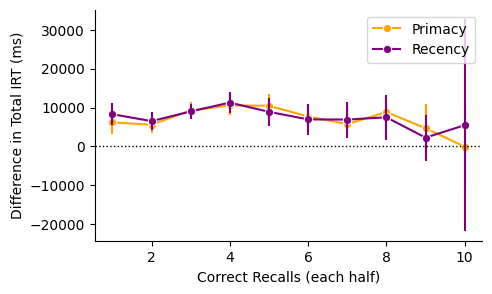

In [463]:
irt.irt_tot_plot(irt_tot_df, path=f'figures/10e_irt_total.pdf')

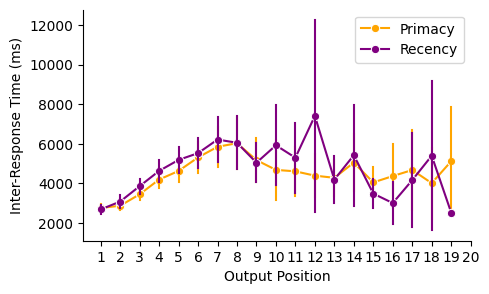

In [459]:
irt_first_df = irt.irt_first_df(filtered_df, n_first=20)
irt.irt_first_plot(irt_first_df, n_first=20, path=f'figures/10d_irt_first.pdf')

In [460]:
for pos in range(1, 21):
    print(f'Output Position {pos}')
    print(stat_tests.condition_contrast(irt_first_df[irt_first_df['output_position']==pos], ['irt'], paired=False))

Output Position 1
  measure   test   n   t_stat     p_val         dof   cohen_d  p_val_fdr
0     irt  welch  61  0.21589  0.829433  122.318315  0.038066   0.829433
Output Position 2
  measure   test   n    t_stat     p_val         dof   cohen_d  p_val_fdr
0     irt  welch  61 -0.429876  0.668008  128.201574 -0.074984   0.668008
Output Position 3
  measure   test   n    t_stat     p_val         dof   cohen_d  p_val_fdr
0     irt  welch  61 -1.361715  0.175918  116.402536 -0.241722   0.175918
Output Position 4
  measure   test   n    t_stat     p_val        dof   cohen_d  p_val_fdr
0     irt  welch  61 -0.912876  0.363202  115.97049 -0.162119   0.363202
Output Position 5
  measure   test   n    t_stat     p_val         dof   cohen_d  p_val_fdr
0     irt  welch  60 -0.589292  0.556748  122.801213 -0.104345   0.556748
Output Position 6
  measure   test   n    t_stat     p_val         dof   cohen_d  p_val_fdr
0     irt  welch  56 -0.639308  0.523858  118.379949 -0.115683   0.523858
Output P

## F11(A-B). Temporal clustering score

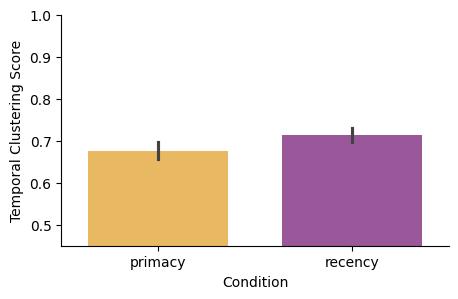

In [488]:
tcl_df = tcl.tcl(filtered_df)
tcl.plot_tcl(tcl_df, path="figures/11a_tcl_overall.pdf")

In [489]:
stat_tests.condition_contrast(tcl_df, ['tcl'], paired=False)

,measure,test,n,t_stat,p_val,dof,cohen_d,p_val_fdr
0,tcl,welch,61,-2.894343,0.004474,126.948469,-0.497854,0.004474


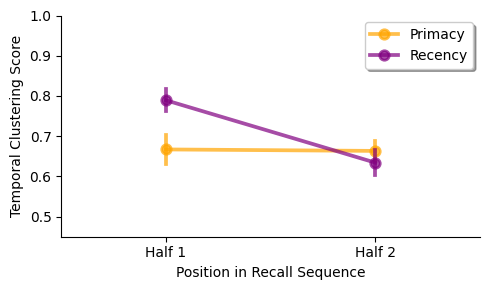

In [490]:
tcl_h_df = tcl.tcl_h(filtered_df)
tcl.plot_tcl_h(tcl_h_df, path="figures/11b_tcl_half.pdf")

In [491]:
stat_tests.condition_contrast(tcl_h_df, ['tcl_h1', 'tcl_h2', 'tcl_delta'], paired=False)

,measure,test,n,t_stat,p_val,dof,cohen_d,p_val_fdr
0,tcl_h1,welch,61,-5.391380,3.391792e-07,124.106255,-0.922964,9.327429e-07
1,tcl_h2,welch,61,1.433563,1.543610e-01,117.127381,0.254284,2.829951e-01
2,tcl_delta,welch,61,6.231924,8.773767e-09,109.575032,1.113578,4.825572e-08


## F11(C) Lag-CRP

Lag-CRP is computed per session, then averaged within participant-condition
before plotting condition curves.


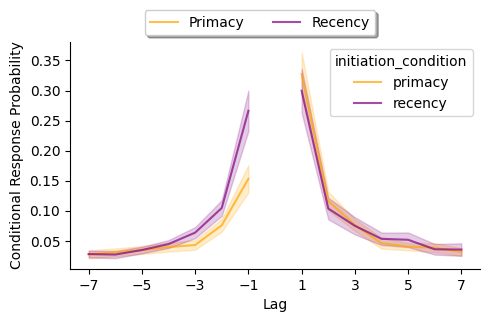

In [492]:
lcrp_df = lcrp.lag_crp(filtered_df)
lcrp.plot_lcrp(lcrp_df, max_lag = 7, path='figures/11c_lcrp.pdf')

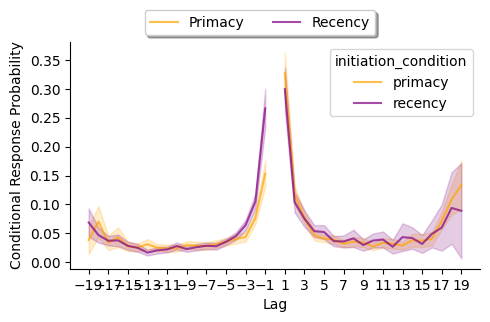

In [493]:
lcrp.plot_lcrp(lcrp_df, max_lag = 19, path='figures/11e_lcrp_full.pdf')

In [494]:
fwd_asym_df = lcrp_df.apply(lambda row: lcrp.forward_asymmetry(row, n=1), axis=1)

stat_tests.condition_contrast(fwd_asym_df, ["asym"], paired=False)

,measure,test,n,t_stat,p_val,dof,cohen_d,p_val_fdr
0,asym,welch,61,4.120135,0.00007,120.815171,0.727822,0.00007


In [495]:
stat_tests.condition_contrast(lcrp_df, ["lp_1", "ln_1"], paired=False)


,measure,test,n,t_stat,p_val,dof,cohen_d,p_val_fdr
0,lp_1,welch,61,1.051834,2.948534e-01,128.255337,0.183438,0.442280
1,ln_1,welch,61,-5.441735,3.357227e-07,107.340357,-0.974364,0.000001


In [496]:
tmp = stat_tests.participant_condition_mean(lcrp_df, ["lp_1", "ln_1"])

tmp.groupby("initiation_condition")[["lp_1", "ln_1"]].agg(["mean", "sem", "count"])

stat_tests.condition_contrast(fwd_asym_df, ["asym"], paired=False)


,measure,test,n,t_stat,p_val,dof,cohen_d,p_val_fdr
0,asym,welch,61,4.120135,0.00007,120.815171,0.727822,0.00007


## F11(d) Semantic Clustering

In [497]:
wordpool = list(np.loadtxt('data/wordpool/wordpool_ltpFR3.txt', dtype=str))
w2v_scores = np.loadtxt('data/wordpool/w2v_scores_ltpFR3.txt')

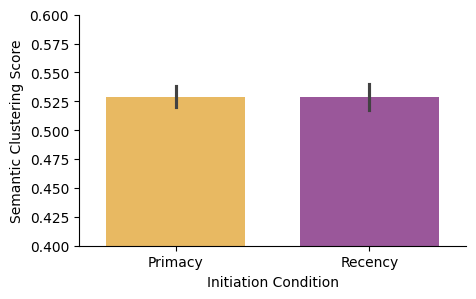

In [498]:
scl_df = scl.scl(filtered_df, wordpool, w2v_scores)
scl.plot_scl(scl_df, path="figures/11d_scl_by_condition.pdf")

In [499]:
stat_tests.one_sample(scl_df, ["scl"], popmean=0.5)

,initiation_condition,measure,test,n,t_stat,p_val,dof,cohen_d,p_val_fdr
0,primacy,scl,one_sample,70,6.241590,3.055665e-08,69,0.746013,9.166995e-08
1,recency,scl,one_sample,61,4.248348,7.616977e-05,60,0.543945,1.142547e-04


In [500]:
# 3) stats
stat_tests.condition_contrast(scl_df, ["scl"], paired=False)

,measure,test,n,t_stat,p_val,dof,cohen_d,p_val_fdr
0,scl,welch,61,0.265687,0.790963,113.383905,0.047305,0.790963
